# Imports

In [ ]:
import psutil
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import pandas as pd
import numpy as np

from graphique.visualisation_EDA import (futuristic_boxplot, plot_histogram,
                                      plot_category_distribution, plot_evolution_category,
                                       plot_scatter_price_quantity, plot_qq_residuals,
                                        plot_elasticity_dashboard, plot_basket_intensity_dashboard )


from IPython.display import display

import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera


# Load and overview datasets

In [2]:
# Data Loading

base_path = Path("..") / "Data" / "raw"

path_local = "C:/Users/Mayeur/Desktop/data/Amazon Sale Report.csv"

df = pd.read_csv(base_path / "International_sale_Report.csv")
df_cat = pd.read_csv(path_local)


# Dataset Overview

print("=== Raw dataset preview ===")
print(df.head(), "\n")

print("=== Dataset shape ===")
print(df.shape, "\n")

print("=== Dataset info ===")
df.info()

print("\n=== Column names ===")
print(df.columns.tolist(), "\n")


# Category Enrichment

print("=== Preparing category dataset ===")

selected_columns = ["Style", "Category"]
df_cat = df_cat[selected_columns]

print("Category dataset preview:")
display(df_cat.head())

# Data Cleaning

print("=== Removing duplicates from category dataset ===")
df_cat = df_cat.drop_duplicates(subset=["Style"])

# Data Merging

print("=== Merging datasets on 'Style' ===")
df = df.merge(df_cat, on="Style")

print("Shape after merge:")
print(df.shape, "\n")


# Memory Usage Analysis

print("=== Memory usage analysis ===")

ram_available = psutil.virtual_memory().available / 1024**3  # GB
ram_df = df.memory_usage(deep=True).sum() / 1024**3  # GB

memory_pressure = (ram_df / ram_available) * 100

process = psutil.Process(os.getpid())
ram_process = process.memory_info().rss / 1024**3  # GB

print(f"Dataset memory usage: {ram_df:.2f} GB")
print(f"Process memory usage: {ram_process:.2f} GB")
print(f"Available RAM: {ram_available:.2f} GB")
print(f"Memory pressure (dataset / available RAM): {memory_pressure:.2f}%")

=== Raw dataset preview ===
   index      DATE  Months            CUSTOMER    Style             SKU Size  \
0      0  06-05-21  Jun-21  REVATHY LOGANATHAN  MEN5004    MEN5004-KR-L    L   
1      1  06-05-21  Jun-21  REVATHY LOGANATHAN  MEN5004   MEN5004-KR-XL   XL   
2      2  06-05-21  Jun-21  REVATHY LOGANATHAN  MEN5004  MEN5004-KR-XXL  XXL   
3      3  06-05-21  Jun-21  REVATHY LOGANATHAN  MEN5009    MEN5009-KR-L    L   
4      4  06-05-21  Jun-21  REVATHY LOGANATHAN  MEN5011    MEN5011-KR-L    L   

    PCS    RATE GROSS AMT  
0  1.00  616.56    617.00  
1  1.00  616.56    617.00  
2  1.00  616.56    617.00  
3  1.00  616.56    617.00  
4  1.00  616.56    617.00   

=== Dataset shape ===
(37432, 10) 

=== Dataset info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37432 entries, 0 to 37431
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      37432 non-null  int64 
 1   DATE       37431 non-null  object

C:\Users\Mayeur\AppData\Local\Temp\ipykernel_23132\1993758574.py:8: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cat = pd.read_csv(path_local)


,Style,Category
0,SET389,Set
1,JNE3781,kurta
2,JNE3371,kurta
3,J0341,Western Dress
4,JNE3671,Top


=== Removing duplicates from category dataset ===
=== Merging datasets on 'Style' ===
Shape after merge:
(35305, 11) 

=== Memory usage analysis ===
Dataset memory usage: 0.02 GB
Process memory usage: 0.24 GB
Available RAM: 52.84 GB
Memory pressure (dataset / available RAM): 0.04%


### Memory Usage Analysis

- The dataset contains approximately **35,305 rows and 11 columns**.

- The dataset occupies around **0.02 GB of RAM**, representing only **4% of the available memory**, indicating very low memory pressure.  
  Pandas is therefore fully sufficient for all EDA and data processing operations.

- The total process memory usage is approximately **1.35 GB**, which remains well within the available RAM (**46.6 GB**), confirming that the environment is not memory-constrained.

- The dataset was enriched through merging operations, allowing the addition of categorical information to the original *"International Sales Report"* dataset.

- Some columns contain mixed data types, which may require additional preprocessing to ensure consistency.



# Data cleaning

- The dataset was filtered to retain only variables relevant to the analysis objective.

- Only a small number of missing values were identified.

- Data types were converted to ensure consistency and proper processing.

- Duplicate records were detected and removed.

- Outliers and inconsistent values were identified and handled.


## Missing values

In [3]:
# Proportion of missing values per columns
prop_na = df.isna().sum()/len(df)
sum_na = df.isna().sum()

print("\n=== Missing values analysis ===\n")

print("Proportion of missing values per column:")
print(prop_na.round(4))

print("\n Number of missing values per column:")
print(sum_na)


=== Missing values analysis ===

Proportion of missing values per column:
index        0.0000
DATE         0.0000
Months       0.0000
CUSTOMER     0.0000
Style        0.0000
SKU          0.0388
Size         0.0000
PCS          0.0000
RATE         0.0000
GROSS AMT    0.0000
Category     0.0000
dtype: float64

 Number of missing values per column:
index           0
DATE            0
Months          0
CUSTOMER        0
Style           0
SKU          1371
Size            0
PCS             0
RATE            0
GROSS AMT       0
Category        0
dtype: int64


## Duplicates values

In [4]:
# Identify duplicated rows based on the 'index' column
filtre_db = df.duplicated(subset="index", keep="first")

nb_doublons = filtre_db.sum()
df_doublons = df[filtre_db]

# Print summary
print("\n=== Duplicate Rows Analysis ===\n")

print(f"Number of duplicated rows: {nb_doublons}")

print("\nDuplicated rows preview:\n")
print(df_doublons.head())

print(f"\nTotal duplicated rows displayed above (first 5 only): {len(df_doublons)}")


=== Duplicate Rows Analysis ===

Number of duplicated rows: 0

Duplicated rows preview:

Empty DataFrame
Columns: [index, DATE, Months, CUSTOMER, Style, SKU, Size, PCS, RATE, GROSS AMT, Category]
Index: []

Total duplicated rows displayed above (first 5 only): 0


  ## Outliers, Inconsistent and Invalid data

-   Mixed-type columns were detected during data loading, highlighting potential data quality issues that need further investigation.

-   Numeric variable

In [5]:
display(df[["PCS","RATE"]].describe())

,PCS,RATE
count,35305,35305
unique,495,1158
top,1.00,425.00
freq,15965,1274


- Categorical variable

In [6]:
df[["CUSTOMER", "Style", "SKU", "Size", "Category"]].describe()

,CUSTOMER,Style,SKU,Size,Category
count,35305,35305,33934,35305,35305
unique,168,977,4501,24,8
top,Feb-22,JNE3555,SET268-KR-NP-L,1.00,kurta
freq,3300,292,62,14684,14600


- Data inconsistencies were identified, with values incorrectly assigned across columns:

  - The **"customer"** column includes date information (month and year).
  - The **"size"** column contains quantity values instead of size information.
  - The **"date"** column contains customer names.

These issues suggest potential data entry or data integration errors.
  

In [7]:
df["Size"].unique()

array(['L', 'XL', 'XXL', 'S', 'M', 'Free', 'XS', 'XXXL', '5XL', '6XL',
       '4XL', 'FREE', '1.00', '2.00', '6.00', '4.00', '3.00', '5.00',
       '15.00', '7.00', '8.00', '12.00', '11.00', '9.00'], dtype=object)

In [8]:

recherche = df[df["CUSTOMER"] == "Feb-22"].sort_values(by="PCS",ascending=False)
recherche

,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT,Category
26830,28594,VISHA DEVAN,02-19-22,Feb-22,SET279,SET279-LC-M,1.00,975.00,975.00,13.00,Set
26550,28287,AVIN,02-08-22,Feb-22,SET353,SET353-KR-NP-XS,1.00,975.00,926.00,20.00,Set
27712,29496,MRS. SUMITHA RAJU,02-25-22,Feb-22,JNE3797,JNE3797-KR-XL,1.00,975.00,926.00,4.00,Western Dress
27711,29495,MRS. SUMITHA RAJU,02-25-22,Feb-22,JNE3797,JNE3797-KR-XXL,1.00,975.00,926.00,3.00,Western Dress
33317,35360,MRS. SUMITHA RAJU,02-25-22,Feb-22,JNE3797,JNE3797-KR-XXL,1.00,975.00,926.00,3.00,Western Dress
...,...,...,...,...,...,...,...,...,...,...,...
33031,35064,ETHNIC WEAVES FASHION LLC,02-22-22,Feb-22,SET327,SET327-KR-DPT-XS,1.00,1000.00,950.00,4.00,Set
33030,35063,ETHNIC WEAVES FASHION LLC,02-22-22,Feb-22,SET327,SET327-KR-DPT-XXXL,1.00,1000.00,950.00,4.00,Set
33283,35325,PUNITHAVATHY KARUPIAH,02-25-22,Feb-22,SET373,SET373-KR-PP-L,1.00,1000.00,950.00,59.00,Set
33284,35326,PUNITHAVATHY KARUPIAH,02-25-22,Feb-22,SET373,SET373-KR-PP-M,1.00,1000.00,950.00,60.00,Set


- To correct these inconsistencies, filtering rules will be applied to identify and isolate anomalous values.

In [9]:
# Detect corrupted rows: numeric values incorrectly stored in the "Size" column
lignes_incohérentes = df["Size"].str.match(r'^\d+(\.\d+)?$', na=False)

# Extract rows with inconsistencies
df_lignes_incohérentes = df[lignes_incohérentes]

# Print corrupted rows (preview)
print("\n=== Corrupted rows preview ===\n")
print(df_lignes_incohérentes.head())

# Print count of valid vs corrupted rows
print("\n=== Inconsistency count ===\n")
print(lignes_incohérentes.value_counts())

# Fix inconsistency: move numeric values from "Size" to "PCS"
df.loc[lignes_incohérentes, "PCS"] = df.loc[lignes_incohérentes, "Size"]


=== Corrupted rows preview ===

       index                DATE    Months CUSTOMER    Style             SKU  \
18321  19676  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5004    MEN5004-KR-L   
18322  19677  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5004   MEN5004-KR-XL   
18323  19678  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5004  MEN5004-KR-XXL   
18324  19679  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5009    MEN5009-KR-L   
18325  19680  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5011    MEN5011-KR-L   

       Size     PCS    RATE GROSS AMT Category  
18321  1.00  616.56  617.00      8.00    kurta  
18322  1.00  616.56  617.00      4.00    kurta  
18323  1.00  616.56  617.00      6.00    kurta  
18324  1.00  616.56  617.00      6.00    kurta  
18325  1.00  616.56  617.00     11.00    kurta  

=== Inconsistency count ===

Size
False    18321
True     16984
Name: count, dtype: int64


In [10]:
# Detect corrupted rows: month-year values incorrectly stored in the "CUSTOMER" column
lignes_incohérentes_V2 = df["CUSTOMER"].str.match(r'^[a-zA-Z]+-\d+$', na=False)

# Extract inconsistent rows
df_lignes_incohérentes_V2 = df[lignes_incohérentes_V2]

# Print preview of corrupted rows
print("\n=== Corrupted rows (CUSTOMER contains month-year) ===\n")
print(df_lignes_incohérentes_V2.head())

# Print count of valid vs corrupted rows
print("\n=== Inconsistency count ===\n")
print(lignes_incohérentes_V2.value_counts())

# Fix inconsistency: move month-year values from "CUSTOMER" to "Months"
df.loc[lignes_incohérentes_V2, "Months"] = df.loc[lignes_incohérentes_V2, "CUSTOMER"]


=== Corrupted rows (CUSTOMER contains month-year) ===

       index                DATE    Months CUSTOMER    Style             SKU  \
18321  19676  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5004    MEN5004-KR-L   
18322  19677  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5004   MEN5004-KR-XL   
18323  19678  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5004  MEN5004-KR-XXL   
18324  19679  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5009    MEN5009-KR-L   
18325  19680  REVATHY LOGANATHAN  06-05-21   Jun-21  MEN5011    MEN5011-KR-L   

       Size   PCS    RATE GROSS AMT Category  
18321  1.00  1.00  617.00      8.00    kurta  
18322  1.00  1.00  617.00      4.00    kurta  
18323  1.00  1.00  617.00      6.00    kurta  
18324  1.00  1.00  617.00      6.00    kurta  
18325  1.00  1.00  617.00     11.00    kurta  

=== Inconsistency count ===

CUSTOMER
False    18321
True     16984
Name: count, dtype: int64


In [11]:
# Detect corrupted rows: date values incorrectly stored in the "Months" column
lignes_incohérentes_V3 = df["Months"].str.match(r'^\d{2}-\d{2}-\d{2}$', na=False)

# Extract inconsistent rows
df_lignes_incohérentes_V3 = df[lignes_incohérentes_V3]

# Print preview of corrupted rows
print("\n=== Corrupted rows (Months contains date format) ===\n")
print(df_lignes_incohérentes_V3.head())

# Print count of valid vs corrupted rows
print("\n=== Inconsistency count ===\n")
print(lignes_incohérentes_V3.value_counts())

# Fix inconsistency: move date values from "Months" to "DATE"
df.loc[lignes_incohérentes_V3, "DATE"] = df.loc[lignes_incohérentes_V3, "Months"]


=== Corrupted rows (Months contains date format) ===

Empty DataFrame
Columns: [index, DATE, Months, CUSTOMER, Style, SKU, Size, PCS, RATE, GROSS AMT, Category]
Index: []

=== Inconsistency count ===

Months
False    35305
Name: count, dtype: int64


In [12]:
# Detect corrupted rows: non-date values incorrectly stored in the "DATE" column
lignes_incohérentes_V4 = ~df["DATE"].str.match(r'^\d{2}-\d{2}-\d{2}$', na=False)

# Extract inconsistent rows
df_lignes_incohérentes_V4 = df[lignes_incohérentes_V4]

# Print preview of corrupted rows
print("\n=== Corrupted rows (DATE contains non-date values) ===\n")
print(df_lignes_incohérentes_V4.head())

# Print count of valid vs corrupted rows
print("\n=== Inconsistency count ===\n")
print(lignes_incohérentes_V4.value_counts())

# Fix inconsistency: move incorrect values from "DATE" to "CUSTOMER"
df.loc[lignes_incohérentes_V4, "CUSTOMER"] = df.loc[lignes_incohérentes_V4, "DATE"]


=== Corrupted rows (DATE contains non-date values) ===

       index                DATE  Months CUSTOMER    Style             SKU  \
18321  19676  REVATHY LOGANATHAN  Jun-21   Jun-21  MEN5004    MEN5004-KR-L   
18322  19677  REVATHY LOGANATHAN  Jun-21   Jun-21  MEN5004   MEN5004-KR-XL   
18323  19678  REVATHY LOGANATHAN  Jun-21   Jun-21  MEN5004  MEN5004-KR-XXL   
18324  19679  REVATHY LOGANATHAN  Jun-21   Jun-21  MEN5009    MEN5009-KR-L   
18325  19680  REVATHY LOGANATHAN  Jun-21   Jun-21  MEN5011    MEN5011-KR-L   

       Size   PCS    RATE GROSS AMT Category  
18321  1.00  1.00  617.00      8.00    kurta  
18322  1.00  1.00  617.00      4.00    kurta  
18323  1.00  1.00  617.00      6.00    kurta  
18324  1.00  1.00  617.00      6.00    kurta  
18325  1.00  1.00  617.00     11.00    kurta  

=== Inconsistency count ===

DATE
False    18321
True     16984
Name: count, dtype: int64


    -   Verifications of corrections

In [13]:
# Validate CUSTOMER column after cleaning

valid_pattern = r'^(\d{2}-\d{2}-\d{2}|[A-Za-z]{3}-\d{2})$'
verif_filtre = ~df["CUSTOMER"].str.match(valid_pattern, na=False)
df_inconsistent_customer = df[verif_filtre]

print("\n=== CUSTOMER validation ===\n")
print(verif_filtre.value_counts().to_string())


=== CUSTOMER validation ===

CUSTOMER
True    35305


In [14]:
# Verification months
df["Months"].unique()

array(['Jun-21', 'Jul-21', 'Aug-21', 'Sep-21', 'Oct-21', 'Nov-21',
       'Dec-21', 'Jan-22', 'Feb-22', 'Mar-22', 'Apr-22', 'May-22'],
      dtype=object)

In [15]:
# Verification of quantity
display(df["PCS"].unique())

array(['1.00', '2.00', '6.00', '4.00', '3.00', '5.00', '15.00', '7.00',
       '8.00', '12.00', '11.00', '9.00'], dtype=object)

## Column type conversion after data corrections

In [16]:
print("=== Column types ===\n")
df.info()

=== Column types ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35305 entries, 0 to 35304
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      35305 non-null  int64 
 1   DATE       35305 non-null  object
 2   Months     35305 non-null  object
 3   CUSTOMER   35305 non-null  object
 4   Style      35305 non-null  object
 5   SKU        33934 non-null  object
 6   Size       35305 non-null  object
 7   PCS        35305 non-null  object
 8   RATE       35305 non-null  object
 9   GROSS AMT  35305 non-null  object
 10  Category   35305 non-null  object
dtypes: int64(1), object(10)
memory usage: 3.0+ MB


-   Variables numériques

In [17]:
# Numerical Variables

df["PCS"] = pd.to_numeric(df["PCS"], errors="coerce").astype("Int64")
print(f"Check data type of quantity variable after conversion: {df['PCS'].dtype}")

df["RATE"] = pd.to_numeric(df["RATE"], errors="coerce").astype("float64")
print(f"Check data type of price variable after conversion: {df['RATE'].dtype}")

df["GROSS AMT"] = pd.to_numeric(df["GROSS AMT"], errors="coerce").astype("float64")
print(f"Check data type of gross amount variable after conversion: {df['GROSS AMT'].dtype}")

print(f"DataFrame shape: {df.shape}")

print(f"Number of conversion errors in PCS: {df['PCS'].isna().sum()}")
print(f"Number of conversion errors in RATE: {df['RATE'].isna().sum()}")
print(f"Number of conversion errors in GROSS AMT: {df['GROSS AMT'].isna().sum()}")



Check data type of quantity variable after conversion: Int64
Check data type of price variable after conversion: float64
Check data type of gross amount variable after conversion: float64
DataFrame shape: (35305, 11)
Number of conversion errors in PCS: 0
Number of conversion errors in RATE: 0
Number of conversion errors in GROSS AMT: 0


-   Variables catégorielles

In [18]:
liste_cat = ["Style","SKU","Category","Size"]
df[liste_cat] = df[liste_cat].astype("category")

print("=== Verification categorical variables ===")
[display(df[col].dtype) for col in liste_cat]

=== Verification categorical variables ===


CategoricalDtype(categories=['AN202', 'AN204', 'AN205', 'AN209', 'BL009', 'BL011',
                  'BL013', 'BL020', 'BL023', 'BL024',
                  ...
                  'SET394', 'SET395', 'SET396', 'SET397', 'SET401', 'SET404',
                  'SET405', 'SET409', 'SET413', 'SET433'],
, ordered=False, categories_dtype=object)

CategoricalDtype(categories=['AN202-ORANGE-L', 'AN202-ORANGE-M', 'AN202-ORANGE-S',
                  'AN202-ORANGE-XL', 'AN202-ORANGE-XXL', 'AN204-PURPLE-M',
                  'AN205-YELLOW-L', 'AN205-YELLOW-M', 'AN205-YELLOW-S',
                  'AN209-BIEGE-XXL',
                  ...
                  'SET409-KR-NP-XL', 'SET409-KR-NP-XS', 'SET409-KR-NP-XXL',
                  'SET413-KR-NP-L', 'SET413-KR-NP-M', 'SET413-KR-NP-S',
                  'SET413-KR-NP-XL', 'SET413-KR-NP-XS', 'SET413-KR-NP-XXL',
                  'SET413-KR-NP-XXXL'],
, ordered=False, categories_dtype=object)

CategoricalDtype(categories=['Blouse', 'Bottom', 'Ethnic Dress', 'Saree', 'Set', 'Top',
                  'Western Dress', 'kurta'],
, ordered=False, categories_dtype=object)

CategoricalDtype(categories=['1.00', '11.00', '12.00', '15.00', '2.00', '3.00', '4.00',
                  '4XL', '5.00', '5XL', '6.00', '6XL', '7.00', '8.00', '9.00',
                  'FREE', 'Free', 'L', 'M', 'S', 'XL', 'XS', 'XXL', 'XXXL'],
, ordered=False, categories_dtype=object)

[None, None, None, None]

-   Date variable

In [19]:
df["DATE"] = pd.to_datetime(
    df["DATE"],
    format='%d-%m-%y',   
    errors='coerce'
)
df["DATE"] = df["DATE"].ffill()
print(f"Check data type of date variable after conversion {df["DATE"].dtype}")


Check data type of date variable after conversion datetime64[ns]


- The applied corrections were effective, significantly improving data quality.  
  For example, the "DATE" column initially contained 18,321 inconsistent rows during detection, which were reduced to 0 after corrections.

## Outlier Visualization and IQR Analysis

-   Boxplot

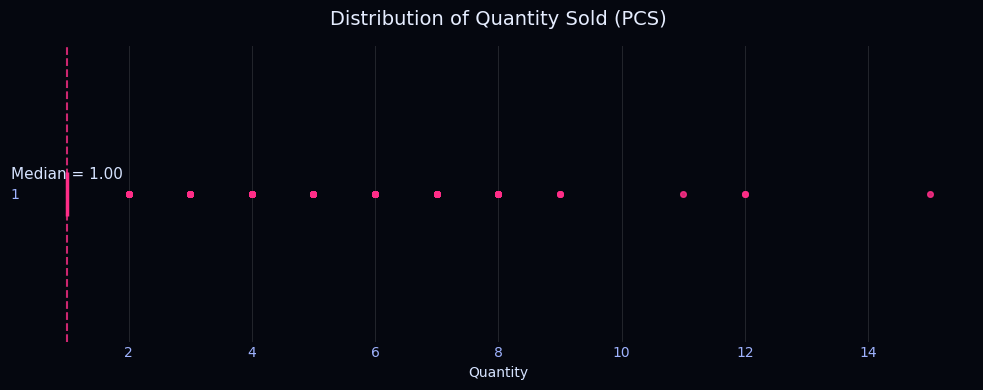

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Quantity Sold (PCS)'}, xlabel='Quantity'>)

In [20]:
futuristic_boxplot(df["PCS"])

    -   Boxplot prix

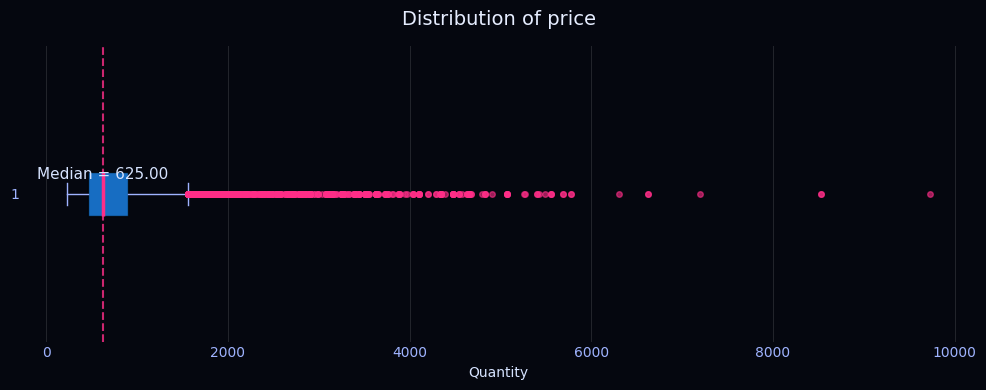

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of price'}, xlabel='Quantity'>)

In [21]:
futuristic_boxplot(df["RATE"],title="Distribution of price")

- IQR

In [22]:
# Outlier quantité
lower_qte = df["PCS"].quantile(0.25)
upper_qte = df["PCS"].quantile(0.75)
IQR_qte = upper_qte - lower_qte

# Bornes quantité
out_sup_qte = upper_qte + (1.5 * IQR_qte)
out_lower_qte = lower_qte - (1.5 * IQR_qte)

# Outlier prix
lower_prix = df["RATE"].quantile(0.25)
upper_prix = df["RATE"].quantile(0.75)
IQR_prix = upper_prix - lower_prix

# Bornes prix
out_sup_prix = upper_prix + (1.5 * IQR_prix)
out_lower_prix = lower_prix - (1.5 * IQR_prix)


outliers_qte = df[
    (df["PCS"] < out_lower_qte) |
    (df["PCS"] > out_sup_qte)
]

outliers_prix = df[
    (df["RATE"] < out_lower_prix) |
    (df["RATE"] > out_sup_prix)
]

# Proportions
prop_outlier_qte = len(outliers_qte) / df.shape[0]
prop_outlier_prix = len(outliers_prix) / df.shape[0]

print(f"Number of quantity outliers : {len(outliers_qte)} that is {prop_outlier_qte} du dataset")
print(f"Number of price outliers : {len(outliers_prix)} that is {prop_outlier_prix} du dataset")

Number of quantity outliers : 4656 that is 0.13187933720436198 du dataset
Number of price outliers : 1535 that is 0.043478260869565216 du dataset


- Comment outliers :
  - Quantity hypothesis, the presence of diffrent customer segmentss, including individual buyers and professional buyer
  - Price hypothesis, the existence of multiple product tiers, such as standard, premium and luxury products
- Conclusion : outliers are retained as they carry mainingful business information 

In [23]:
# List of products with higher prices

top_prix = df[["RATE","Category"]].sort_values(by="RATE",ascending= False)
print("=== List of products with higher prices === \n")
print(top_prix)

# Average  price per category
prix_mean = df.groupby("Category",observed=True)["RATE"].mean().sort_values(ascending=False)
print("=== Average  price per category === \n")
print(prix_mean)

=== List of products with higher prices === 

         RATE Category
18852  9735.0    kurta
23975  8526.0      Set
29581  8526.0      Set
20319  7202.0      Set
29585  6625.0      Set
...       ...      ...
34654   231.0      Top
33061   227.0   Blouse
27454   227.0   Blouse
27455   227.0   Blouse
33060   227.0   Blouse

[35305 rows x 2 columns]
=== Average  price per category === 

Category
Set              1066.112378
Ethnic Dress      988.471196
Western Dress     836.900997
Saree             739.022059
Bottom            602.370441
kurta             573.961806
Top               542.563543
Blouse            373.522924
Name: RATE, dtype: float64


-   The highest kurta price is significantly above the mean, suggesting a potential inconsistency. At this stage, it is retained pending confirmation through univariate and bivariate analysis.

In [24]:
# Most expensive products by category and style
style_price = (
    df.groupby(["Category", "Style"], observed=True)["RATE"]
      .max()
      .sort_values(ascending=False)
)

print("=== Ranking of the most expensive products by category and style ===\n")
print(style_price)


# Use the unfiltered dataset to compare with gross amount
print("=== Sample of products for Style = 'MEN5021' ===\n")
display(df[df["Style"] == "MEN5021"].head())

print("=== Minimum price in the dataset ===")
print(f"Minimum price: {df['RATE'].min()}")

=== Ranking of the most expensive products by category and style ===

Category      Style  
kurta         MEN5021    9735.00
Set           J0277      8526.00
              J0239      7202.00
              J0242      6625.00
Ethnic Dress  J0001      6307.00
                          ...   
Bottom        AN202       281.00
              AN205       281.00
              AN204       281.00
Blouse        BL086       255.56
Top           J0300       244.00
Name: RATE, Length: 977, dtype: float64
=== Sample of products for Style = 'MEN5021' ===



,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT,Category
531,535,2021-11-06,Jun-21,SYEDA MORSHED,MEN5021,MEN5021-KR-M,M,15,649.0,9735.0,kurta
532,536,2021-11-06,Jun-21,SYEDA MORSHED,MEN5021,MEN5021-KR-S,S,6,649.0,3894.0,kurta
533,537,2021-11-06,Jun-21,SYEDA MORSHED,MEN5021,MEN5021-KR-XL,XL,7,649.0,4543.0,kurta
534,538,2021-11-06,Jun-21,SYEDA MORSHED,MEN5021,MEN5021-KR-L,L,5,649.0,3245.0,kurta
535,539,2021-11-06,Jun-21,SYEDA MORSHED,MEN5021,MEN5021-KR-XXL,XXL,2,649.0,1298.0,kurta


=== Minimum price in the dataset ===
Minimum price: 227.0


-   Inconsistencies are observed in the GROSS AMT and RATE columns. The values currently recorded in the RATE column appear to correspond to those in GROSS AMT
-   Correction to apply, copy the price values into the GROSS AMT column, and recompute the price as GROSS AMT / PCS to obtain a more consistent and approximatite unit price for subsequent analysis.

In [25]:
# Values below the minimum price in GROSS AMT are considered inconsistent

df.loc[df['GROSS AMT'] < 220, 'RATE'] = (
    df['RATE'] / df['PCS']
)

In [26]:
# Verification

verif_prix = df[
    (df["Category"] == "kurta") &
    (df["RATE"] > 700 ) &
    (df["DATE"] >= "2022-04-01") &
    (df["DATE"] <= "2022-07-31") 
]
print("Verification price values \n")
verif_prix

Verification price values 



,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT,Category
7515,7593,2022-04-01,Jan-22,K.PARTHIBAN,JNE3749,JNE3749-KR-L,L,1,738.0,738.0,kurta
9852,9992,2022-05-03,Mar-22,IBRAHIM MAFTHOOH(JANASYA.IN),J0373,J0373-KR-M,M,1,812.5,772.0,kurta
9865,10005,2022-05-03,Mar-22,IBRAHIM MAFTHOOH(JANASYA.IN),JNE3727,JNE3727-KR-M,M,1,737.5,701.0,kurta
13121,13289,2022-04-01,Jan-22,K.PARTHIBAN,JNE3749,JNE3749-KR-L,L,1,738.0,738.0,kurta
15458,15688,2022-05-03,Mar-22,IBRAHIM MAFTHOOH(JANASYA.IN),J0373,J0373-KR-M,M,1,812.5,772.0,kurta
15471,15701,2022-05-03,Mar-22,IBRAHIM MAFTHOOH(JANASYA.IN),JNE3727,JNE3727-KR-M,M,1,737.5,701.0,kurta
15910,16148,2022-05-03,Mar-22,IBRAHIM MAFTHOOH(JANASYA.IN),J0373,J0373-KR-M,M,1,812.5,772.0,kurta
15923,16161,2022-05-03,Mar-22,IBRAHIM MAFTHOOH(JANASYA.IN),JNE3727,JNE3727-KR-M,M,1,737.5,701.0,kurta
17343,17602,2022-06-04,Apr-22,Natheliya,J0328,NaN,M,2,1037.5,2075.0,kurta
17344,17603,2022-06-04,Apr-22,Natheliya,J0328,NaN,L,3,1037.5,3112.5,kurta


-   The peak observed in the univariate analysis is not due to an inconsistency, but rather to a premium product

In [27]:
# Customers who purchase the highest quantities by category

big_customers = (
    df.groupby(["CUSTOMER", "Category"], observed=True)["PCS"]
      .sum()
      .sort_values(ascending=False)
)

print("=== Top customers by purchase quantity (per category) ===\n")
print(big_customers)

=== Top customers by purchase quantity (per category) ===

CUSTOMER                            Category
MULBERRIES BOUTIQUE                 Set         2326
BHANU SALEINE NAUNITHAM             kurta       1584
AMANI CONCEPT TRADING LLC (KAPDA)   Bottom      1456
MULBERRIES BOUTIQUE                 kurta       1167
GALAXY GROUP OF COMPANIES PVT. LTD  Set          888
                                                ... 
Dishanu Fashion World               kurta          1
Chaaya Sookdeb                      kurta          1
Babitha huxley                      Set            1
Mrs Sumitha Raju                    Set            1
Avin                                Set            1
Name: PCS, Length: 513, dtype: Int64


-   Professional customer segments are identified as the source of bulk purchasing behavior, thereby confirming the hypothesis related to quantity outliers.

## Df clean and filtrer

In [28]:
# Remove variables outside the scope of the analysis

selected_columns = ["DATE", "SKU", "Months", "Style", "PCS", "RATE", "Category"]

df_seg = df[selected_columns].rename(columns={
    "PCS": "quantity",
    "RATE": "price"
})

print("=== Segmentation dataset preview ===\n")
display(df_seg.head())

print("=== Dataset dimensions ===\n")
print(f"Segmentation dataset shape: {df_seg.shape}")
print(f"Original dataset shape: {df.shape}")

=== Segmentation dataset preview ===



,DATE,SKU,Months,Style,quantity,price,Category
0,2021-05-06,MEN5004-KR-L,Jun-21,MEN5004,1,616.56,kurta
1,2021-05-06,MEN5004-KR-XL,Jun-21,MEN5004,1,616.56,kurta
2,2021-05-06,MEN5004-KR-XXL,Jun-21,MEN5004,1,616.56,kurta
3,2021-05-06,MEN5009-KR-L,Jun-21,MEN5009,1,616.56,kurta
4,2021-05-06,MEN5011-KR-L,Jun-21,MEN5011,1,616.56,kurta


=== Dataset dimensions ===

Segmentation dataset shape: (35305, 7)
Original dataset shape: (35305, 11)


# Analysis

## Univariate analysis

### Analysis of numeric variables

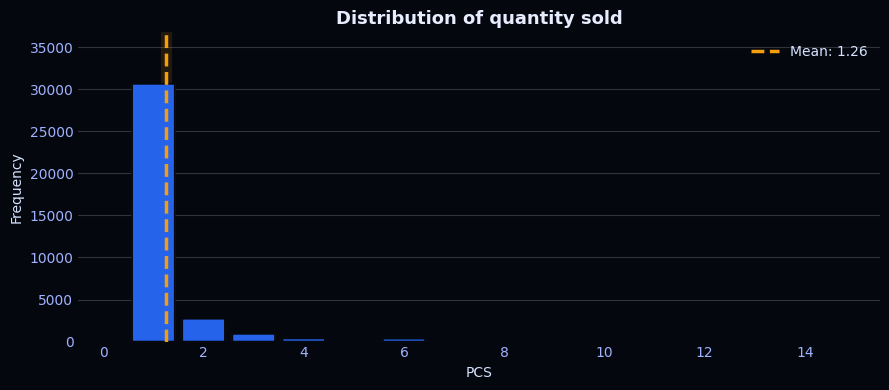

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of quantity sold'}, xlabel='PCS', ylabel='Frequency'>)

In [29]:
# Distribution of quantity sold
plot_histogram(
    df["PCS"],
    title="Distribution of quantity sold",
    xlabel="PCS",
    discrete=True
)

In [30]:
# Distribution of the number of items sold per transaction (in percentage)

dist = df_seg["quantity"].value_counts(normalize=True) * 100

print("=== Distribution of quantity per transaction (%) ===\n")
print(dist.sort_index())

=== Distribution of quantity per transaction (%) ===

quantity
1     86.812066
2      7.690129
3      2.600198
4      1.050843
5      0.402209
6      0.991361
7      0.062314
8      0.351225
9      0.016995
11     0.005665
12      0.01133
15     0.005665
Name: proportion, dtype: Float64


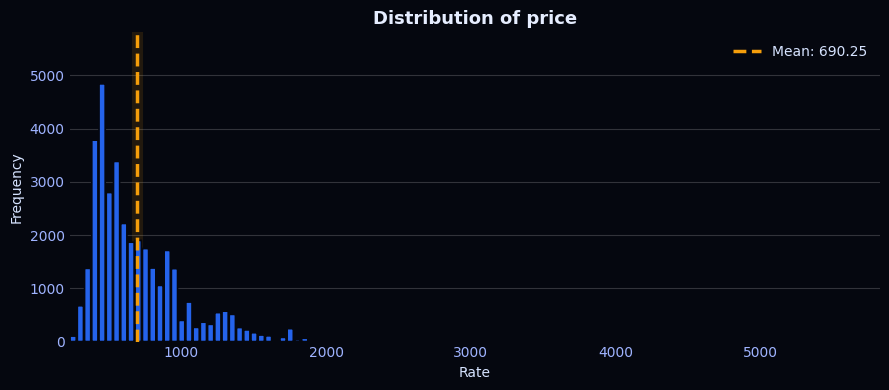

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of price'}, xlabel='Rate', ylabel='Frequency'>)

In [31]:
# Distribution of price
plot_histogram(
    df["RATE"],
    title="Distribution of price",
    xlabel="Rate",
    bin_width=50
)

### Analysis of categorical variables

In [32]:
# Sales distribution by SKU, Style, and Category

sku_distribution = df_seg["SKU"].value_counts(ascending=False)
style_distribution = df_seg["Style"].value_counts(ascending=False)
category_distribution = df_seg["Category"].value_counts(ascending=False)


# Distribution of SKU frequencies grouped into intervals
sku_group = (
    pd.cut(
        df_seg["SKU"].value_counts(),
        bins=[0, 10, 30, float("inf")],
        labels=["0-10", "11-30", "30+"]
    )
    .value_counts()
    .sort_index()
)

# Distribution of Style frequencies grouped into intervals
style_group = (
    pd.cut(
        df_seg["Style"].value_counts(),
        bins=[0, 10, 30, float("inf")],
        labels=["0-10", "11-30", "30+"]
    )
    .value_counts()
    .sort_index()
)


print("=== SKU Distribution ===\n")
print(sku_distribution, "\n")

print("=== SKU Frequency Groups (for encoding) ===\n")
print(sku_group, "\n")

print("=== Style Frequency Groups (for encoding) ===\n")
print(style_group, "\n")

print("=== Style Distribution ===\n")
print(style_distribution, "\n")

print("=== Category Distribution ===\n")
print(category_distribution)

=== SKU Distribution ===

SKU
SET268-KR-NP-L     62
JNE3555-KR-L       58
JNE3548-KR-M       54
JNE3440-KR-L       52
SET268-KR-NP-M     50
                   ..
BL024-74RED         2
BL023-74PINK        2
BL013-62BLACK       2
BL011-62PINK        2
AN209-BIEGE-XXL     2
Name: count, Length: 4501, dtype: int64 

=== SKU Frequency Groups (for encoding) ===

count
0-10     3591
11-30     859
30+        51
Name: count, dtype: int64 

=== Style Frequency Groups (for encoding) ===

count
0-10     243
11-30    306
30+      428
Name: count, dtype: int64 

=== Style Distribution ===

Style
JNE3555    292
SET268     284
JNE3548    267
JNE3440    227
JNE3489    204
          ... 
J0413        1
J0419        1
JNE3902      1
SET364       1
SET369       1
Name: count, Length: 977, dtype: int64 

=== Category Distribution ===

Category
kurta            14600
Set              12391
Top               4796
Western Dress     1494
Bottom            1044
Ethnic Dress       669
Blouse             277
Sare

-    SKU is highly imbalanced; therefore, it is not retained for modeling.
-    Style does not exhibit extreme imbalance.

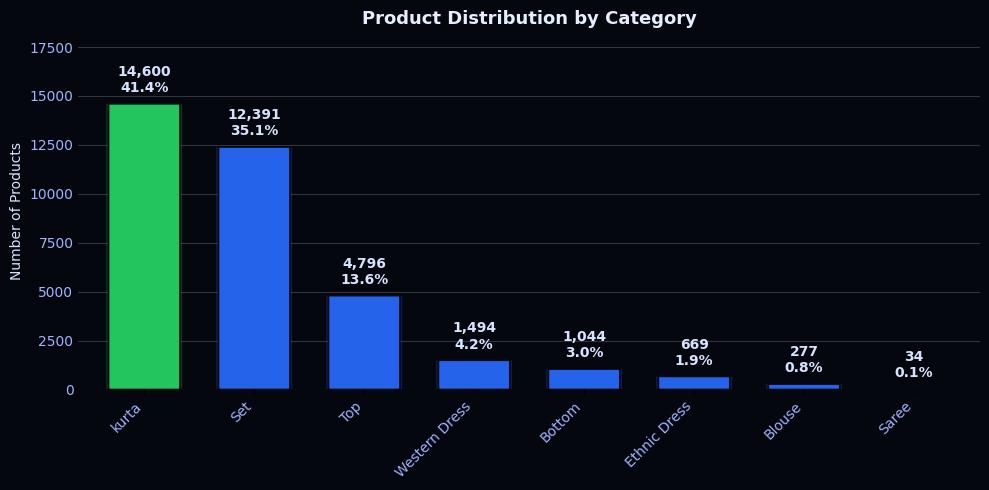

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Product Distribution by Category'}, ylabel='Number of Products'>)

In [33]:
repat_cat = df["Category"].value_counts()
plot_category_distribution(repat_cat)

## Bivariate analysis

### Correlation analysis

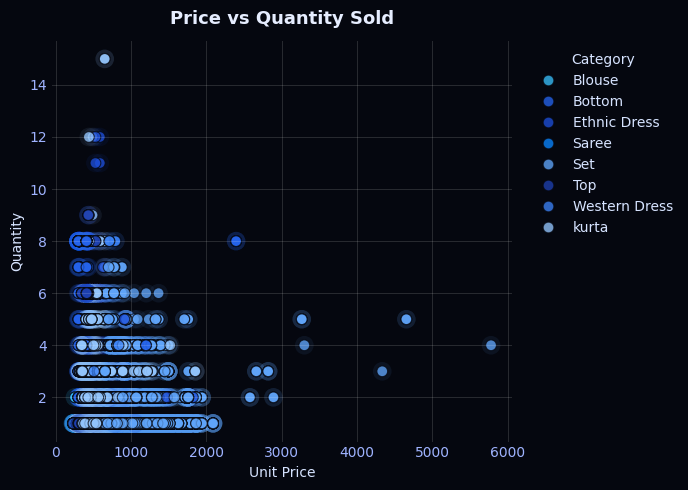

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Price vs Quantity Sold'}, xlabel='Unit Price', ylabel='Quantity'>)

In [34]:
plot_scatter_price_quantity(df_seg)

-   Certain categories, including Kurta, Bottom, and Top, show a positive correlation between variables.

-   The Set category exhibits a weak correlation between price and quantity.

-   No significant correlation is identified between price and quantity for the Ethnic Dress category.

-   Globally, there is no evidence of a linear relationship between price and quantity

### Trend analysis 

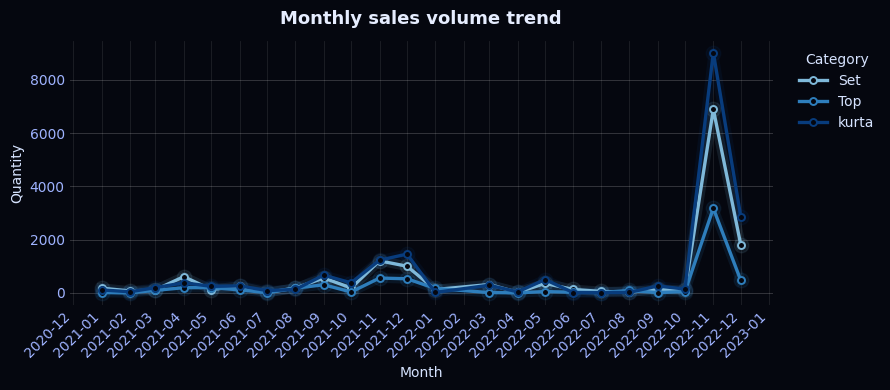

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Monthly sales volume trend'}, xlabel='Month', ylabel='Quantity'>)

In [35]:
plot_evolution_category(
    df=df_seg,
    value_col="quantity",
    categories=["Set", "kurta", "Top"],
    agg="sum",
    title="Monthly sales volume trend",
    ylabel="Quantity"
)


-   The behavior of the three products is similar, with two significant peaks marked by sharp increases at the end of each year. These patterns may be driven by year-end holidays and/or promotional periods such as Black Friday.

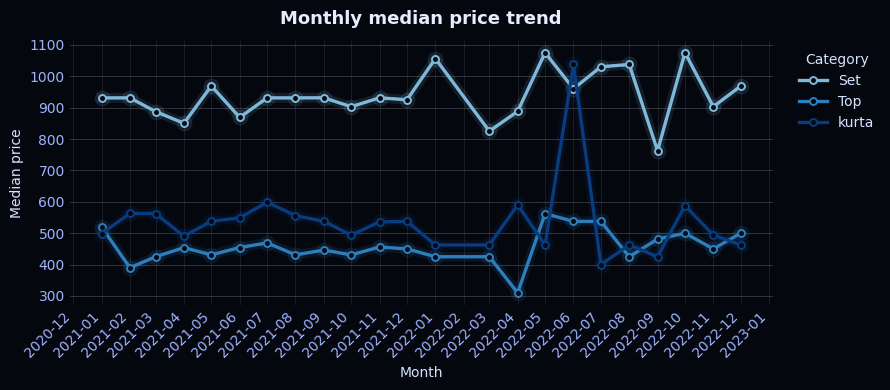

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Monthly median price trend'}, xlabel='Month', ylabel='Median price'>)

In [36]:
plot_evolution_category(
    df=df_seg,
    value_col="price",
    categories=["Set", "kurta", "Top"],
    agg="median",
    title="Monthly median price trend",
    ylabel="Median price"
)


-   For the Set category, prices remain relatively stable between $800 and $1,100, with two distinct periods; price variation is lower in 2021 than in 2022.

-   For the Kurta category, prices range between $400 and $600, with a noticeable spike in May 2022 that may indicate a pricing error or data inconsistency.

-   For the Top category, prices remain stable between $300 and $550

## Statistical test

- Normalité 

In [37]:
df_seg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35305 entries, 0 to 35304
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DATE      35305 non-null  datetime64[ns]
 1   SKU       33934 non-null  category      
 2   Months    35305 non-null  object        
 3   Style     35305 non-null  category      
 4   quantity  35305 non-null  Int64         
 5   price     35305 non-null  float64       
 6   Category  35305 non-null  category      
dtypes: Int64(1), category(3), datetime64[ns](1), float64(1), object(1)
memory usage: 1.5+ MB


Encoding completed. Shape after encoding: (35305, 988)
Feature matrix shape: (35305, 984)
Target shape: (35305,)

=== Model Training (OLS) ===

Model successfully trained.

                            OLS Regression Results                            
Dep. Variable:               quantity   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     10.09
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:13:46   Log-Likelihood:                -40722.
No. Observations:               35305   AIC:                         8.340e+04
Df Residuals:                   34327   BIC:                         9.168e+04
Df Model:                         977                                         
Covariance Type:            nonrobust                                         
                             coef    

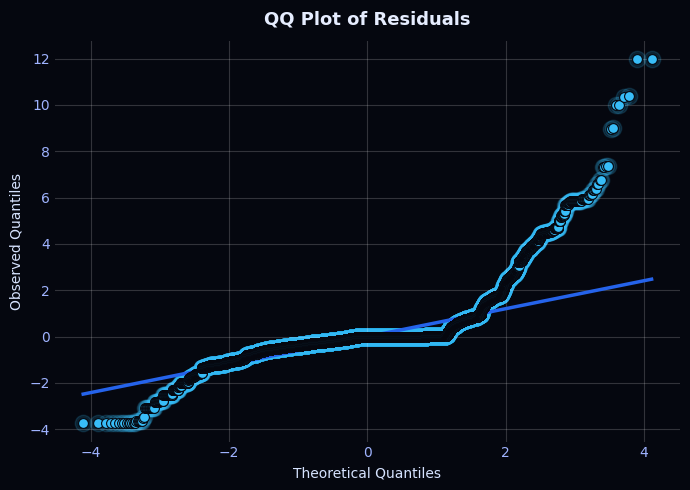

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'QQ Plot of Residuals'}, xlabel='Theoretical Quantiles', ylabel='Observed Quantiles'>)

In [38]:
# Columns to exclude from modeling
cols_to_ignore = ["DATE", "Months", "SKU"]

# Encoding for categorical variables
df_test_stat = pd.get_dummies(
    df_seg,
    columns=["Category", "Style"],
    drop_first=True,
    dtype=float
)

print("Encoding completed. Shape after encoding:", df_test_stat.shape)

# Split features and target
X = df_test_stat.drop(columns=cols_to_ignore + ["quantity"])
y = df_test_stat["quantity"].astype(float)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Model Training (OLS)

print("\n=== Model Training (OLS) ===\n")

# Add constant for intercept
X = sm.add_constant(X, has_constant="add")

# Fit OLS model
model = sm.OLS(y, X).fit()

print("Model successfully trained.\n")
print(model.summary())


print("\n=== Residual Analysis ===\n")

# Extract residuals
residuals = model.resid

# Jarque-Bera test for normality
jb_stat, jb_pvalue, skew, kurt = jarque_bera(residuals)

print(f"Jarque-Bera statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.4f}")
print(f"Skewness: {skew:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# Visualization

print("\n=== Residual Visualization ===\n")

# QQ plot of residuals
plot_qq_residuals(residuals)

- The OLS model highlights the presence of a statistically significant linear signal between some explanatory variables and the quantity sold. However, its explanatory power remains limited (R² ≈ 0.22), indicating that a large portion of the variance is not captured by linear relationships.

- The high dimensionality resulting from categorical encoding (≈ 1000 features) introduces a strong risk of multicollinearity. This leads to unstable coefficients that are not robust and difficult to interpret from an economic perspective.

- Residual analysis using the QQ plot shows a clear deviation from normality, with noticeable skewness, heavy tails, and the presence of significant outliers. The very high kurtosis further confirms a strongly leptokurtic distribution, indicating high noise levels and a non-Gaussian target distribution.

- These findings suggest that key OLS assumptions (normality of residuals and homoscedasticity) are violated, limiting the reliability of statistical inference.

- This analysis serves as an exploratory step to detect initial linear signals and diagnose the limitations of the model.

- It justifies the use of more robust and non-linear machine learning models (e.g., Random Forest, Gradient Boosting), which are better suited to capture complex patterns and handle non-standard data distributions.

## Price Elasticity

-   rolling price elasticity

In [39]:
def elast_rolling(
    df,
    group_cols=("SKU", "Style", "Category"),
    date_col="DATE",
    qty_col="quantity",
    price_col="price",
    window=14,
    min_periods=5,
    clip_abs=10,
):
    """
    Compute rolling price elasticity of demand using log-differences.

    The function calculates local elasticity based on log variations of quantity
    and price, then smooths it using a rolling mean for each grouping level.

    Args:
        df (pd.DataFrame): Input dataset containing price and quantity data.
        group_cols (tuple): Columns used to group the data (e.g., SKU, Style, Category).
        date_col (str): Column representing time ordering.
        qty_col (str): Column representing quantity sold.
        price_col (str): Column representing price.
        window (int): Rolling window size.
        min_periods (int): Minimum observations required for rolling computation.
        clip_abs (float): Maximum absolute value allowed for elasticity (outlier control).

    Returns:
        pd.DataFrame: DataFrame with additional columns:
            - dlog_qty_<group>: lagged log-difference of quantity
            - dlog_price_<group>: lagged log-difference of price
            - elasticite_locale_<group>: local elasticity
            - elasticite_rolling_<group>: smoothed rolling elasticity
    """

    
    df_out = df.copy()

    df_out = df_out.sort_values(list(group_cols) + [date_col])

    # Compute log-transformed variables
    df_out["log_qty"] = np.log1p(df_out[qty_col])  # log(1 + quantity) to handle zeros
    df_out["log_price"] = np.where(
        df_out[price_col] > 0,
        np.log(df_out[price_col]),
        np.nan
    )  

    # Loop over each grouping level
    for col in group_cols:

        # Define dynamic column names
        dlog_qty_col = f"dlog_qty_{col}"
        dlog_price_col = f"dlog_price_{col}"
        elas_loc_col = f"elasticite_locale_{col}"
        elas_roll_col = f"elasticite_rolling_{col}"

        df_out = df_out.sort_values([col, date_col])

        # Compute raw log-differences 
        dlog_qty_raw = df_out.groupby(col, observed=True)["log_qty"].diff()
        dlog_price_raw = df_out.groupby(col, observed=True)["log_price"].diff()

        # Shift to ensure only past information is used 
        df_out[dlog_qty_col] = dlog_qty_raw.groupby(df_out[col], observed=True).shift(1)
        df_out[dlog_price_col] = dlog_price_raw.groupby(df_out[col], observed=True).shift(1)

        # Compute local elasticity
        df_out[elas_loc_col] = dlog_qty_raw / dlog_price_raw

        # Remove infinite values caused by division by zero
        df_out[elas_loc_col] = df_out[elas_loc_col].replace([np.inf, -np.inf], np.nan)

        # Clip extreme elasticity values
        df_out[elas_loc_col] = df_out[elas_loc_col].mask(
            df_out[elas_loc_col].abs() > clip_abs
        )

        # Compute rolling mean of elasticity
        df_out[elas_roll_col] = (
            df_out.groupby(col, observed=True)[elas_loc_col]
            .transform(
                lambda x: x.rolling(
                    window=window,
                    min_periods=min_periods
                ).mean().shift(1)
            )
        )

    # Remove intermediate log column
    df_out = df_out.drop(columns=["log_qty"])

    return df_out

In [40]:
df_seg = elast_rolling(
    df_seg,
    group_cols=("SKU", "Style", "Category"),
    window=14,
    min_periods=5
)

In [41]:
df_seg.columns

Index(['DATE', 'SKU', 'Months', 'Style', 'quantity', 'price', 'Category',
       'log_price', 'dlog_qty_SKU', 'dlog_price_SKU', 'elasticite_locale_SKU',
       'elasticite_rolling_SKU', 'dlog_qty_Style', 'dlog_price_Style',
       'elasticite_locale_Style', 'elasticite_rolling_Style',
       'dlog_qty_Category', 'dlog_price_Category',
       'elasticite_locale_Category', 'elasticite_rolling_Category'],
      dtype='object')

- Variance 

In [42]:
def elast_variance(df, group_cols=("SKU", "Style", "Category"),
                   date_col="DATE",
                   window=14, min_periods=5,
                   ddof=1):
    """
    Compute rolling variance of price elasticity.

    Args:
        df: Input DataFrame.
        group_cols (tuple): Grouping columns.
        date_col (str): Date column name.
        window (int): Rolling window size.
        min_periods (int): Minimum periods for rolling variance.
        ddof (int): Delta degrees of freedom.

    Returns:
        pd.DataFrame: DataFrame with rolling elasticity variance features.
    """
    df_out = df.copy()

    for col in group_cols:

        elas_loc_col = f"elasticite_locale_{col}"
        var_roll_col = f"var_elasticite_rolling_{col}"

        if elas_loc_col not in df_out.columns:
            raise ValueError(f"Missing column: {elas_loc_col}")

        # Sort data by group and date
        df_out = df_out.sort_values([col, date_col])

        # Rolling variance
        df_out[var_roll_col] = (
            df_out.groupby(col, observed=True)[elas_loc_col]
                  .transform(
                      lambda x: x.rolling(window=window, min_periods=min_periods)
                                 .var(ddof=ddof)
                                 .shift(1)
                  )
        )

        # Drop intermediate local elasticity column
        df_out.drop(columns=[elas_loc_col], inplace=True)

    return df_out

In [43]:
df_seg = elast_variance(
    df_seg,
    group_cols=("SKU","Style","Category"),
    window=14,
    min_periods=5,
)

- Verification 

In [44]:
df_seg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35305 entries, 6065 to 17919
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   DATE                             35305 non-null  datetime64[ns]
 1   SKU                              33934 non-null  category      
 2   Months                           35305 non-null  object        
 3   Style                            35305 non-null  category      
 4   quantity                         35305 non-null  Int64         
 5   price                            35305 non-null  float64       
 6   Category                         35305 non-null  category      
 7   log_price                        35305 non-null  float64       
 8   dlog_qty_SKU                     24932 non-null  Float64       
 9   dlog_price_SKU                   24932 non-null  float64       
 10  elasticite_rolling_SKU           5718 non-null   float64    

-   Presence of missing data

In [45]:
def fill_elast_features(df, date_col="DATE"):
    """
    Fill missing elasticity and variance features.

    Args:
        df: Input DataFrame.
        date_col (str): Date column name.

    Returns:
        pd.DataFrame: DataFrame with filled features and imputation flags.
    """
    df = df.copy()

    sku_cols = ["elasticite_rolling_SKU", "var_elasticite_rolling_SKU"]
    cat_cols = ["elasticite_rolling_Category", "var_elasticite_rolling_Category"]
    style_cols = ["elasticite_rolling_Style", "var_elasticite_rolling_Style"]

    all_cols = sku_cols + cat_cols + style_cols

    df = df.sort_values(date_col)

    # Create imputation flags
    for col in all_cols:
        df[f"flag_imputed_{col}"] = df[col].isna().astype("int8")

    # Compute global historical medians by date
    global_history_map = {}
    for col in all_cols:
        median_by_date = (
            df.groupby(date_col, observed=True)[col]
              .median()
              .sort_index()
        )

        historical_global_median = (
            median_by_date.expanding(min_periods=1)
                          .median()
                          .shift(1)
        )

        global_history_map[col] = df[date_col].map(historical_global_median).astype(float)

    # Fill one grouped series
    def _fill_groupwise(series, fallback_series):
        # Forward fill from past values
        s = series.ffill()

        # Historical median within group
        hist_med = s.expanding(min_periods=1).median().shift(1)

        # Fill with group history first
        s = s.fillna(hist_med)

        # Fallback to global history
        s = s.fillna(fallback_series)

        return s.fillna(0.0)

    # Apply filling by group level
    def apply_fill(group_col: str, cols: list[str]):
        nonlocal df
        df = df.sort_values([group_col, date_col])

        for col in cols:
            fallback_series = global_history_map[col].reindex(df.index)

            df[col] = (
                df.groupby(group_col, observed=True)[col]
                  .transform(lambda x: _fill_groupwise(x, fallback_series.loc[x.index]))
            )

    apply_fill("SKU", sku_cols)
    apply_fill("Category", cat_cols)
    apply_fill("Style", style_cols)

    return df

In [46]:
df_seg = fill_elast_features(df_seg)
df_seg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35305 entries, 2605 to 17700
Data columns (total 26 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   DATE                                          35305 non-null  datetime64[ns]
 1   SKU                                           33934 non-null  category      
 2   Months                                        35305 non-null  object        
 3   Style                                         35305 non-null  category      
 4   quantity                                      35305 non-null  Int64         
 5   price                                         35305 non-null  float64       
 6   Category                                      35305 non-null  category      
 7   log_price                                     35305 non-null  float64       
 8   dlog_qty_SKU                                  24932 non-null  Float6

-   Top categories and SKUs with the highest elasticity variance

In [47]:
# Top categories and SKUs with the highest elasticity variance

# Category level
top5_cat_var = (
    df_seg
    .groupby("Category", observed=True)["var_elasticite_rolling_Category"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(3)
    .index
)


# SKU level 
# Filter out SKUs with insufficient observations
min_obs = 25

valid_skus = (
    df_seg
    .groupby("SKU", observed=True)["var_elasticite_rolling_SKU"]
    .count()
    .loc[lambda x: x > min_obs]
    .index
)

top5_sku_var = (
    df_seg[df_seg["SKU"].isin(valid_skus)]
    .groupby("SKU", observed=True)["var_elasticite_rolling_SKU"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
)


print("=== Top Categories by Elasticity Variance ===\n")
print(top5_cat_var, "\n")

print("=== Top SKUs by Elasticity Variance (filtered by minimum observations) ===\n")
print(top5_sku_var)

=== Top Categories by Elasticity Variance ===

CategoricalIndex(['Saree', 'Bottom', 'kurta'], categories=['Blouse', 'Bottom', 'Ethnic Dress', 'Saree', 'Set', 'Top', 'Western Dress', 'kurta'], ordered=False, dtype='category', name='Category') 

=== Top SKUs by Elasticity Variance (filtered by minimum observations) ===

CategoricalIndex(['JNE3576-KR-M', 'JNE3405-KR-L', 'J0277-SKD-M'], categories=['AN202-ORANGE-L', 'AN202-ORANGE-M', 'AN202-ORANGE-S', 'AN202-ORANGE-XL', ..., 'SET413-KR-NP-XL', 'SET413-KR-NP-XS', 'SET413-KR-NP-XXL', 'SET413-KR-NP-XXXL'], ordered=False, dtype='category', name='SKU')


- Top 5 des SKU les plus vendus

In [48]:
# Top-selling categories and SKUs (by quantity)

# Category level
top5_cat_vente = (
    df_seg
    .groupby("Category", observed=True)["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# SKU level
top5_SKU_vente = (
    df_seg
    .groupby("SKU", observed=True)["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

print("=== Top 3 Categories by Sales Volume ===\n")
print(top5_cat_vente, "\n")

print("=== Top 3 SKUs by Sales Volume ===\n")
print(top5_SKU_vente)

=== Top 3 Categories by Sales Volume ===

CategoricalIndex(['kurta', 'Set', 'Top'], categories=['Blouse', 'Bottom', 'Ethnic Dress', 'Saree', 'Set', 'Top', 'Western Dress', 'kurta'], ordered=False, dtype='category', name='Category') 

=== Top 3 SKUs by Sales Volume ===

CategoricalIndex(['SET268-KR-NP-L', 'JNE3640-TP-XL', 'JNE3640-TP-L'], categories=['AN202-ORANGE-L', 'AN202-ORANGE-M', 'AN202-ORANGE-S', 'AN202-ORANGE-XL', ..., 'SET413-KR-NP-XL', 'SET413-KR-NP-XS', 'SET413-KR-NP-XXL', 'SET413-KR-NP-XXXL'], ordered=False, dtype='category', name='SKU')


-   Visualisation

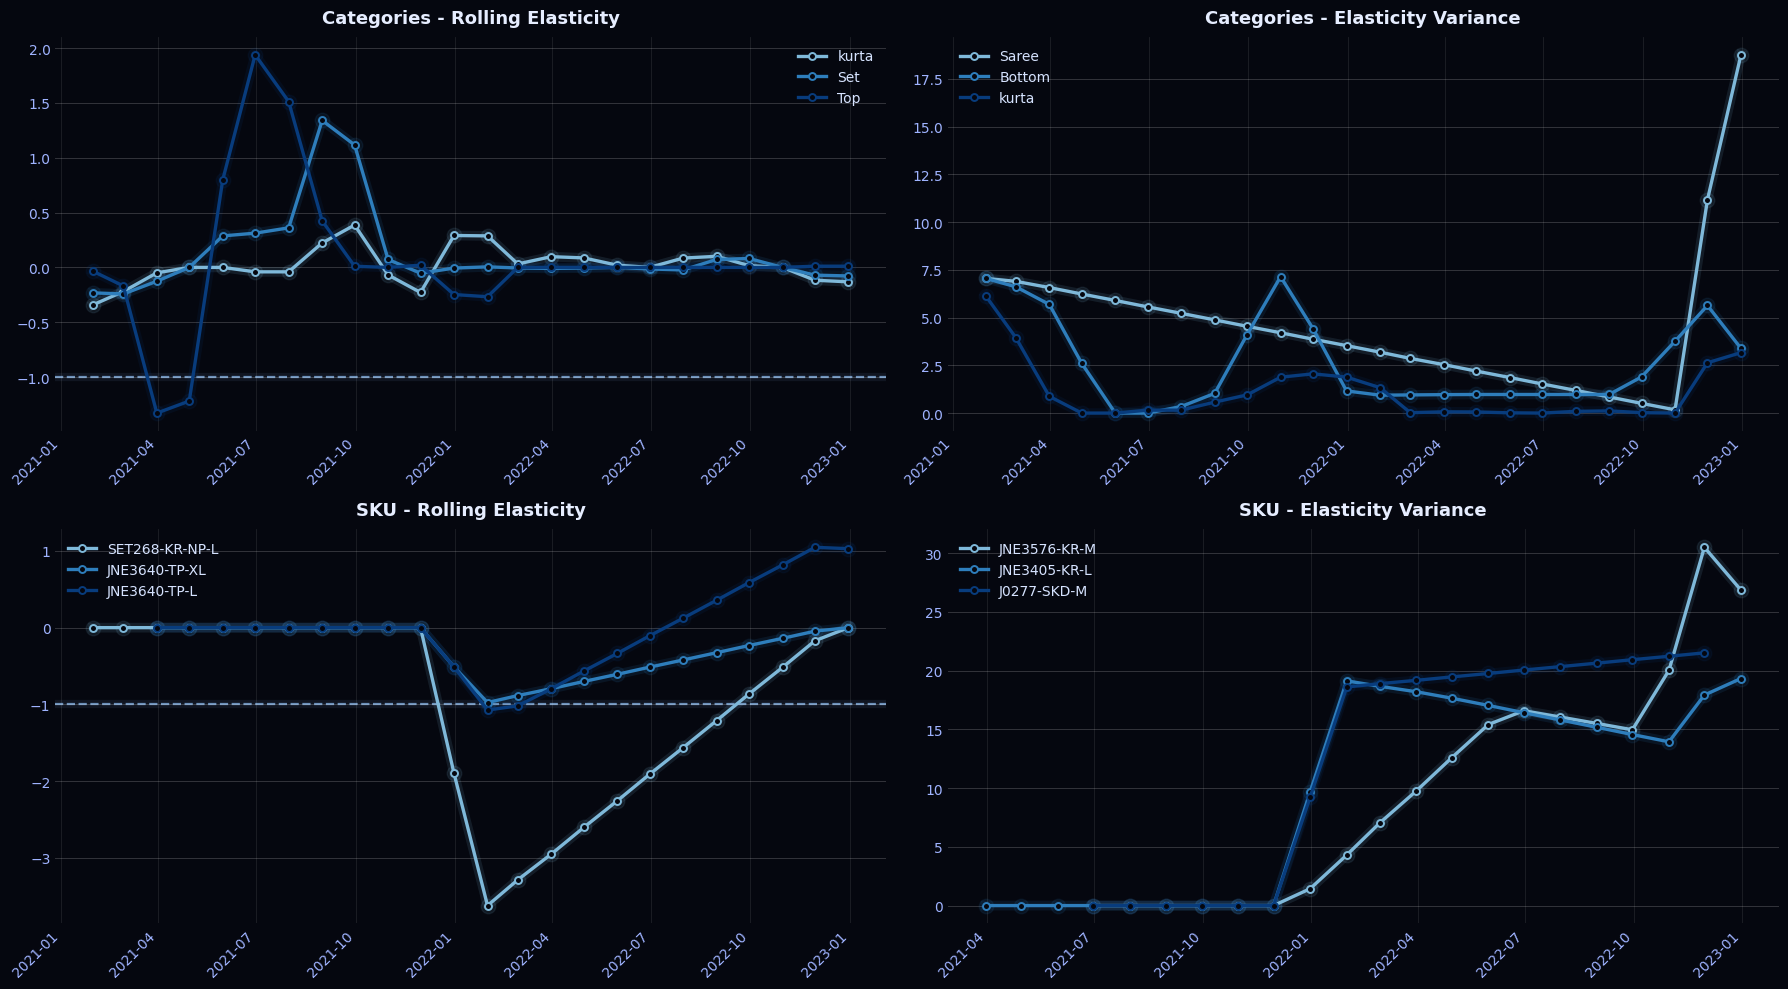

(<Figure size 1800x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Categories - Rolling Elasticity'}>,
         <Axes: title={'center': 'Categories - Elasticity Variance'}>],
        [<Axes: title={'center': 'SKU - Rolling Elasticity'}>,
         <Axes: title={'center': 'SKU - Elasticity Variance'}>]],
       dtype=object))

In [49]:
plot_elasticity_dashboard(
    df=df_seg,
    top_categories_sales=top5_cat_vente,
    top_categories_variance=top5_cat_var,
    top_skus_sales=top5_SKU_vente,
    top_skus_variance=top5_sku_var,
)

-   Category-level analysis
    -   Kurta exhibits an elasticity consistently close to zero throughout the period, indicating low price sensitivity and therefore a relatively inelastic and stable demand.
    -   Set and Top show larger fluctuations in elasticity during 2021, including both positive and negative spikes. This suggests that sales were more responsive to price changes,      potentially due to promotional activity or pricing strategy adjustments.

    -   The elasticity variance highlights differences in stability across categories:

        -   Saree displays high variance, indicating a more volatile and less predictable response to price changes.
        -   In contrast, Kurta maintains low variance, confirming a stable and resilient demand pattern
  
-   SKU-level analysis

    -   Some SKUs exhibit nearly constant elasticity (often close to -1 or 0), indicating a stable price-demand relationship over time.
    -   Other SKUs show a significant increase in elasticity variance, especially from 2022 onward, reflecting a more unstable and evolving price sensitivity.

    -   The pronounced fluctuations (sharp drops followed by recoveries) may be driven by:
        -   pricing strategy changes,
        -   promotional effects,
        -   structural shifts in demand dynamics

## Basket intensity proxy

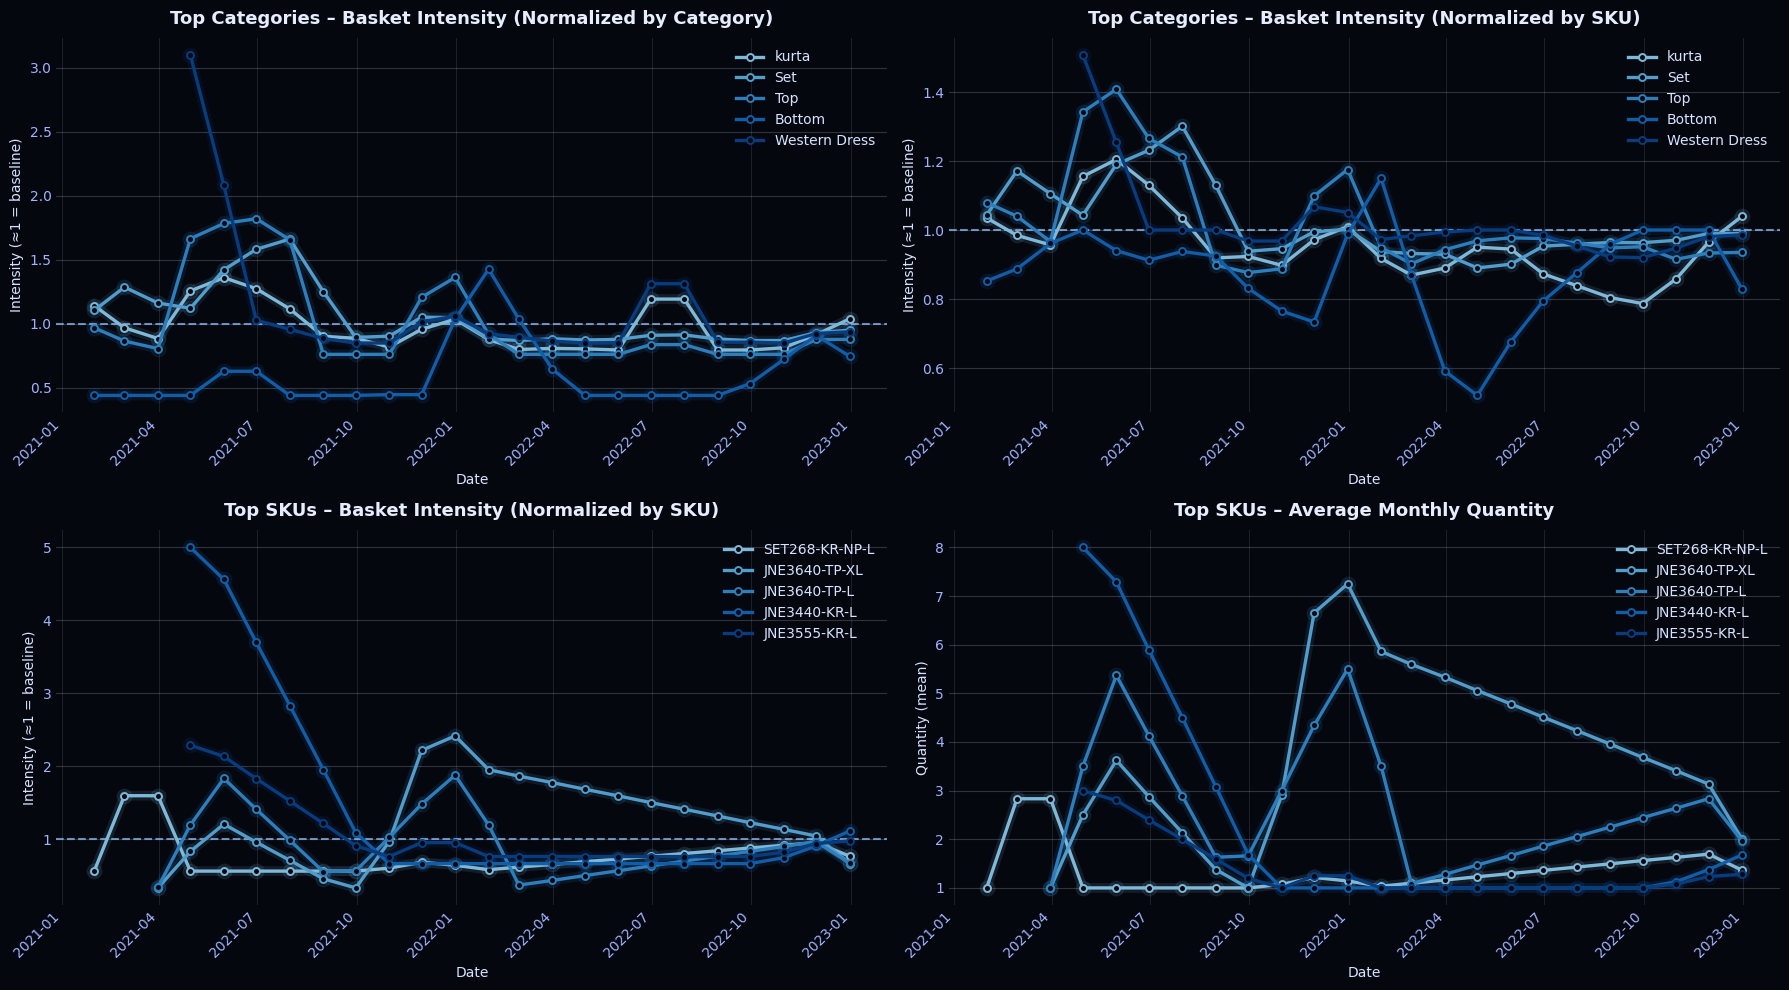

(<Figure size 1800x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Top Categories – Basket Intensity (Normalized by Category)'}, xlabel='Date', ylabel='Intensity (≈1 = baseline)'>,
         <Axes: title={'center': 'Top Categories – Basket Intensity (Normalized by SKU)'}, xlabel='Date', ylabel='Intensity (≈1 = baseline)'>],
        [<Axes: title={'center': 'Top SKUs – Basket Intensity (Normalized by SKU)'}, xlabel='Date', ylabel='Intensity (≈1 = baseline)'>,
         <Axes: title={'center': 'Top SKUs – Average Monthly Quantity'}, xlabel='Date', ylabel='Quantity (mean)'>]],
       dtype=object))

In [50]:
df_seg = df_seg.copy()
df_seg["DATE"] = pd.to_datetime(df_seg["DATE"])
df_seg = df_seg.sort_values(["DATE", "SKU"])


# Basket intensity proxy

df_seg["sku_mean_qty"] = df_seg.groupby("SKU", observed=True)["quantity"].transform("mean")
df_seg["style_mean_qty"] = df_seg.groupby("Style", observed=True)["quantity"].transform("mean")
df_seg["cat_mean_qty"] = df_seg.groupby("Category", observed=True)["quantity"].transform("mean")


df_seg["basket_intensity_sku_norm"] = df_seg["quantity"] / df_seg["sku_mean_qty"]
df_seg["basket_intensity_style_norm"] = df_seg["quantity"] / df_seg["style_mean_qty"]
df_seg["basket_intensity_cat_norm"] = df_seg["quantity"] / df_seg["cat_mean_qty"]

# limite les outliers pour l'échelle
df_seg["basket_intensity_sku_norm_plot"] = df_seg["basket_intensity_sku_norm"].clip(0, 5)
df_seg["basket_intensity_style_norm_plot"] = df_seg["basket_intensity_style_norm"].clip(0, 5)
df_seg["basket_intensity_cat_norm_plot"] = df_seg["basket_intensity_cat_norm"].clip(0, 5)


top5_sku_sales = (
    df_seg.groupby("SKU", observed=True)["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

top5_cat_sales = (
    df_seg.groupby("Category", observed=True)["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

top5_style_sales = (
    df_seg.groupby("Style", observed=True)["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

plot_basket_intensity_dashboard(
    df=df_seg,
    top_categories=top5_cat_sales,
    top_skus=top5_sku_sales
)


-   Basket intensity – Top categories (norm cat):
Top and Set show periods where basket intensity rises above the average, indicating that they are more frequently included in purchases at certain times. In contrast, Bottom often remains below the average, suggesting a lower presence in customer baskets.

-   Basket intensity – Top categories (norm SKU):
Variations are more moderate, and categories remain generally close to the average. This indicates that, once normalized at the SKU level, differences between categories become less pronounced and basket presence is relatively stable.

-   Basket intensity – Top SKU (norm SKU):
Some products exhibit spikes in intensity during specific periods, indicating that they are particularly prominent in purchases at those times. However, most SKUs tend to revert to the average afterward, suggesting overall stable demand in the long run.

-   Monthly mean quantity – Top SKU:
Quantities sold vary across products and periods. Some SKUs experience temporary increases in sales, which may reflect periods of strong demand, while others maintain more consistent sales volumes over time.

# Data featuring

## ML 2 datasets :
-   One without aggregation
-   One with daily aggregation, including lag features and moving averages


-   Feature time 

In [51]:
df_feature_1 = df_seg.copy()

# Calendar features
df_feature_1['year'] = df_feature_1['DATE'].dt.year
df_feature_1['Months'] = df_feature_1['DATE'].dt.month
df_feature_1['day'] = df_feature_1['DATE'].dt.day
df_feature_1['week'] = df_feature_1['DATE'].dt.isocalendar().week.astype(int)

# Cyclical encoding for month
df_feature_1['month_sin'] = np.sin(2 * np.pi * df_feature_1['Months'] / 12)
df_feature_1['month_cos'] = np.cos(2 * np.pi * df_feature_1['Months'] / 12)

# Cyclical encoding for day
df_feature_1['day_sin'] = np.sin(2 * np.pi * df_feature_1['day'] / 7)
df_feature_1['day_cos'] = np.cos(2 * np.pi * df_feature_1['day'] / 7)

# Cyclical encoding for week
df_feature_1['week_sin'] = np.sin(2 * np.pi * df_feature_1['week'] / 52)
df_feature_1['week_cos'] = np.cos(2 * np.pi * df_feature_1['week'] / 52)


-   Addition of seasonal features

In [52]:
df_feature_1["mmdd"] = df_feature_1["DATE"].dt.month * 100 + df_feature_1["DATE"].dt.day

df_feature_1["saison"] = 3  # Winter
df_feature_1.loc[(df_feature_1["mmdd"] >= 320) & (df_feature_1["mmdd"] < 621), "saison"] = 0  # Spring
df_feature_1.loc[(df_feature_1["mmdd"] >= 621) & (df_feature_1["mmdd"] < 923), "saison"] = 1  # Summer
df_feature_1.loc[(df_feature_1["mmdd"] >= 923) & (df_feature_1["mmdd"] < 1221), "saison"] = 2 # Autumn



-   Daily aggregation

In [53]:
# Aggregation rules
agg_dict = {
    # Main variables
    "quantity": "sum",
    "price": "mean",

    # Calendar variables
    "saison": "first",
    "Months": "first",
    "week": "first",
    "year": "first",
    "day": "first",
    "mmdd": "first",

    # Cyclical encoding
    "month_sin": "first",
    "month_cos": "first",
    "week_sin": "first",
    "week_cos": "first",
    "day_sin": "first",
    "day_cos": "first",

    # Log variables
    "log_price": "mean",

    # Log differences
    "dlog_qty_SKU": "mean",
    "dlog_price_SKU": "mean",
    "dlog_qty_Style": "mean",
    "dlog_price_Style": "mean",
    "dlog_qty_Category": "mean",
    "dlog_price_Category": "mean",

    # Elasticities
    "elasticite_rolling_SKU": "mean",
    "elasticite_rolling_Style": "mean",
    "elasticite_rolling_Category": "mean",

    # Elasticity variance
    "var_elasticite_rolling_SKU": "mean",
    "var_elasticite_rolling_Style": "mean",
    "var_elasticite_rolling_Category": "mean",

    # Imputation flags
    "flag_imputed_elasticite_rolling_SKU": "max",
    "flag_imputed_var_elasticite_rolling_SKU": "max",
    "flag_imputed_elasticite_rolling_Category": "max",
    "flag_imputed_var_elasticite_rolling_Category": "max",
    "flag_imputed_elasticite_rolling_Style": "max",
    "flag_imputed_var_elasticite_rolling_Style": "max"
}

# Grouping and sorting by category and date
df_feature_2 = (
    df_feature_1.groupby(["Category", "DATE"], observed=True, as_index=False)
          .agg(agg_dict)
          .sort_values(["Category", "DATE"])
)

out = []

for cat, g in df_feature_2.groupby("Category", observed=True):
    g = (
        g.set_index("DATE")
         .sort_index()
         .asfreq("D")   
    )

    g["Category"] = cat
    g["quantity"] = g["quantity"].fillna(0)

    out.append(g)

df_feature_2 = pd.concat(out).reset_index()

print("df_seg:", df_feature_2.shape)
print(df_feature_2.columns)



df_seg: (5411, 35)
Index(['DATE', 'Category', 'quantity', 'price', 'saison', 'Months', 'week',
       'year', 'day', 'mmdd', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'day_sin', 'day_cos', 'log_price', 'dlog_qty_SKU', 'dlog_price_SKU',
       'dlog_qty_Style', 'dlog_price_Style', 'dlog_qty_Category',
       'dlog_price_Category', 'elasticite_rolling_SKU',
       'elasticite_rolling_Style', 'elasticite_rolling_Category',
       'var_elasticite_rolling_SKU', 'var_elasticite_rolling_Style',
       'var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_SKU',
       'flag_imputed_var_elasticite_rolling_SKU',
       'flag_imputed_elasticite_rolling_Category',
       'flag_imputed_var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_Style',
       'flag_imputed_var_elasticite_rolling_Style'],
      dtype='object')


-   Addition of rolling features

In [54]:
def rolling(df, window=(7, 14, 28)):
    """
    Compute rolling mean and std features by category.

    Args:
        df: Input DataFrame.
        window (tuple): Rolling window sizes.

    Returns:
        pd.DataFrame: DataFrame with rolling features.
    """
    df = df.sort_values(["Category", "DATE"]).copy()

    g = df.groupby("Category", observed=True)["quantity"]

    for w in window:
        # Shift to avoid leakage, then compute rolling stats
        s = g.shift(1).rolling(window=w, min_periods=w)
        df[f"roll_mean_{w}"] = s.mean()
        df[f"roll_std_{w}"] = s.std()

    cols = [c for c in df.columns if c.startswith("roll_")]
    df = df.dropna(subset=cols).reset_index(drop=True)

    return df


df_feature_2 = rolling(df_feature_2)

-   Addition of lag features

In [55]:
def lag(
    df,
    lags=(1, 7, 14, 28),
    group_col="Category",
    date_col="DATE",
    target_col="quantity"
):
    """
    Create lag features for a target variable.

    Args:
        df: Input DataFrame.
        lags (tuple): Lag values.
        group_col (str): Grouping column.
        date_col (str): Date column.
        target_col (str): Target variable.

    Returns:
        pd.DataFrame: DataFrame with lag features.
    """
    df = df.sort_values([group_col, date_col]).copy()

    for l in lags:
        # Compute lag per group
        df[f"lag_{l}"] = (
            df.groupby(group_col, observed=True)[target_col]
              .shift(l)
        )

    # Drop rows with missing lag values
    lag_cols = [f"lag_{l}" for l in lags]
    df = df.dropna(subset=lag_cols).reset_index(drop=True)

    return df


df_feature_2 = lag(df_feature_2)

# Final verification

### Filter to remove columns that are not relevant to the objective

In [56]:
print(f"dimension du df_feature_1 {df_feature_1.shape}")
print(f"Type des varaibles {df_feature_1.info()}")
col_del_f1 = ["mmdd","Months","day","week","SKU","basket_intensity_sku_norm_plot",
              "basket_intensity_cat_norm_plot","cat_mean_qty","sku_mean_qty",
              "basket_intensity_sku_norm", "basket_intensity_cat_norm"]
df_feature_1 = df_feature_1.drop(col_del_f1, axis = 1)
print(df_feature_1.columns)

dimension du df_feature_1 (35305, 46)
<class 'pandas.core.frame.DataFrame'>
Index: 35305 entries, 707 to 17700
Data columns (total 46 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   DATE                                          35305 non-null  datetime64[ns]
 1   SKU                                           33934 non-null  category      
 2   Months                                        35305 non-null  int32         
 3   Style                                         35305 non-null  category      
 4   quantity                                      35305 non-null  Int64         
 5   price                                         35305 non-null  float64       
 6   Category                                      35305 non-null  category      
 7   log_price                                     35305 non-null  float64       
 8   dlog_qty_SKU                   

In [57]:
col_del_f2 = ["mmdd","Months","day","week"]
df_feature_2 = df_feature_2.drop(col_del_f2, axis = 1)
print(df_feature_2.columns)
print(f"Dimension du df_feature_2 {df_feature_2.shape}")


Index(['DATE', 'Category', 'quantity', 'price', 'saison', 'year', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'day_sin', 'day_cos', 'log_price',
       'dlog_qty_SKU', 'dlog_price_SKU', 'dlog_qty_Style', 'dlog_price_Style',
       'dlog_qty_Category', 'dlog_price_Category', 'elasticite_rolling_SKU',
       'elasticite_rolling_Style', 'elasticite_rolling_Category',
       'var_elasticite_rolling_SKU', 'var_elasticite_rolling_Style',
       'var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_SKU',
       'flag_imputed_var_elasticite_rolling_SKU',
       'flag_imputed_elasticite_rolling_Category',
       'flag_imputed_var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_Style',
       'flag_imputed_var_elasticite_rolling_Style', 'roll_mean_7',
       'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28',
       'roll_std_28', 'lag_1', 'lag_7', 'lag_14', 'lag_28'],
      dtype='object')
Dimension du df_feature_2 (4963, 41)


In [58]:
df_feature_1.to_csv(r"..\Data\processed\data_df_feature_1.csv")
df_feature_2.to_csv(r"..\Data\processed\data_df_feature_2.csv")